<a href="https://colab.research.google.com/github/jellybbie/study/blob/project3/Colab_%EC%8B%9C%EC%9E%91%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 건조 실험

In [1]:
import pandas as pd

### Load the data

I'll load the `/content/drought stress-v3.xlsx` file into a pandas DataFrame and display the first 5 rows to ensure it's loaded correctly.

In [2]:
file_path = '/content/drought stress-v3.xlsx'
df = pd.read_excel(file_path)
display(df.head())

,Type,Strain,repeat1,repeat2,repeat3
0,Bacteria,1R-RH9-M1-A6,1.0,1.0,1.0
1,Bacteria,1R-RH9-M1-B2,1.0,1.0,0.0
2,Bacteria,1R-RH9-M1-B3,1.0,1.0,0.0
3,Bacteria,2R-RH6-M1-F5,1.0,0.5,1.0
4,Bacteria,2R-RH6-M1-F6,0.5,1.0,0.5


### Data Processing for Visualization

First, I'll calculate the average drought resistance score from the `repeat1`, `repeat2`, and `repeat3` columns for each strain. This will give us a single metric to compare strains.


In [3]:
df['average_resistance'] = df[['repeat1', 'repeat2', 'repeat3']].mean(axis=1)

# Display the DataFrame with the new average resistance column
display(df.head())

,Type,Strain,repeat1,repeat2,repeat3,average_resistance
0,Bacteria,1R-RH9-M1-A6,1.0,1.0,1.0,1.000000
1,Bacteria,1R-RH9-M1-B2,1.0,1.0,0.0,0.666667
2,Bacteria,1R-RH9-M1-B3,1.0,1.0,0.0,0.666667
3,Bacteria,2R-RH6-M1-F5,1.0,0.5,1.0,0.833333
4,Bacteria,2R-RH6-M1-F6,0.5,1.0,0.5,0.666667


### Visualization of Drought Resistance

Now, I'll create a bar plot to visualize the average drought resistance score for each strain. The strains will be grouped and colored by their 'Type' (Bacteria, Yeast, Lactic Acid Bacteria, Bacillus, etc.), allowing for easy comparison across different organism types.


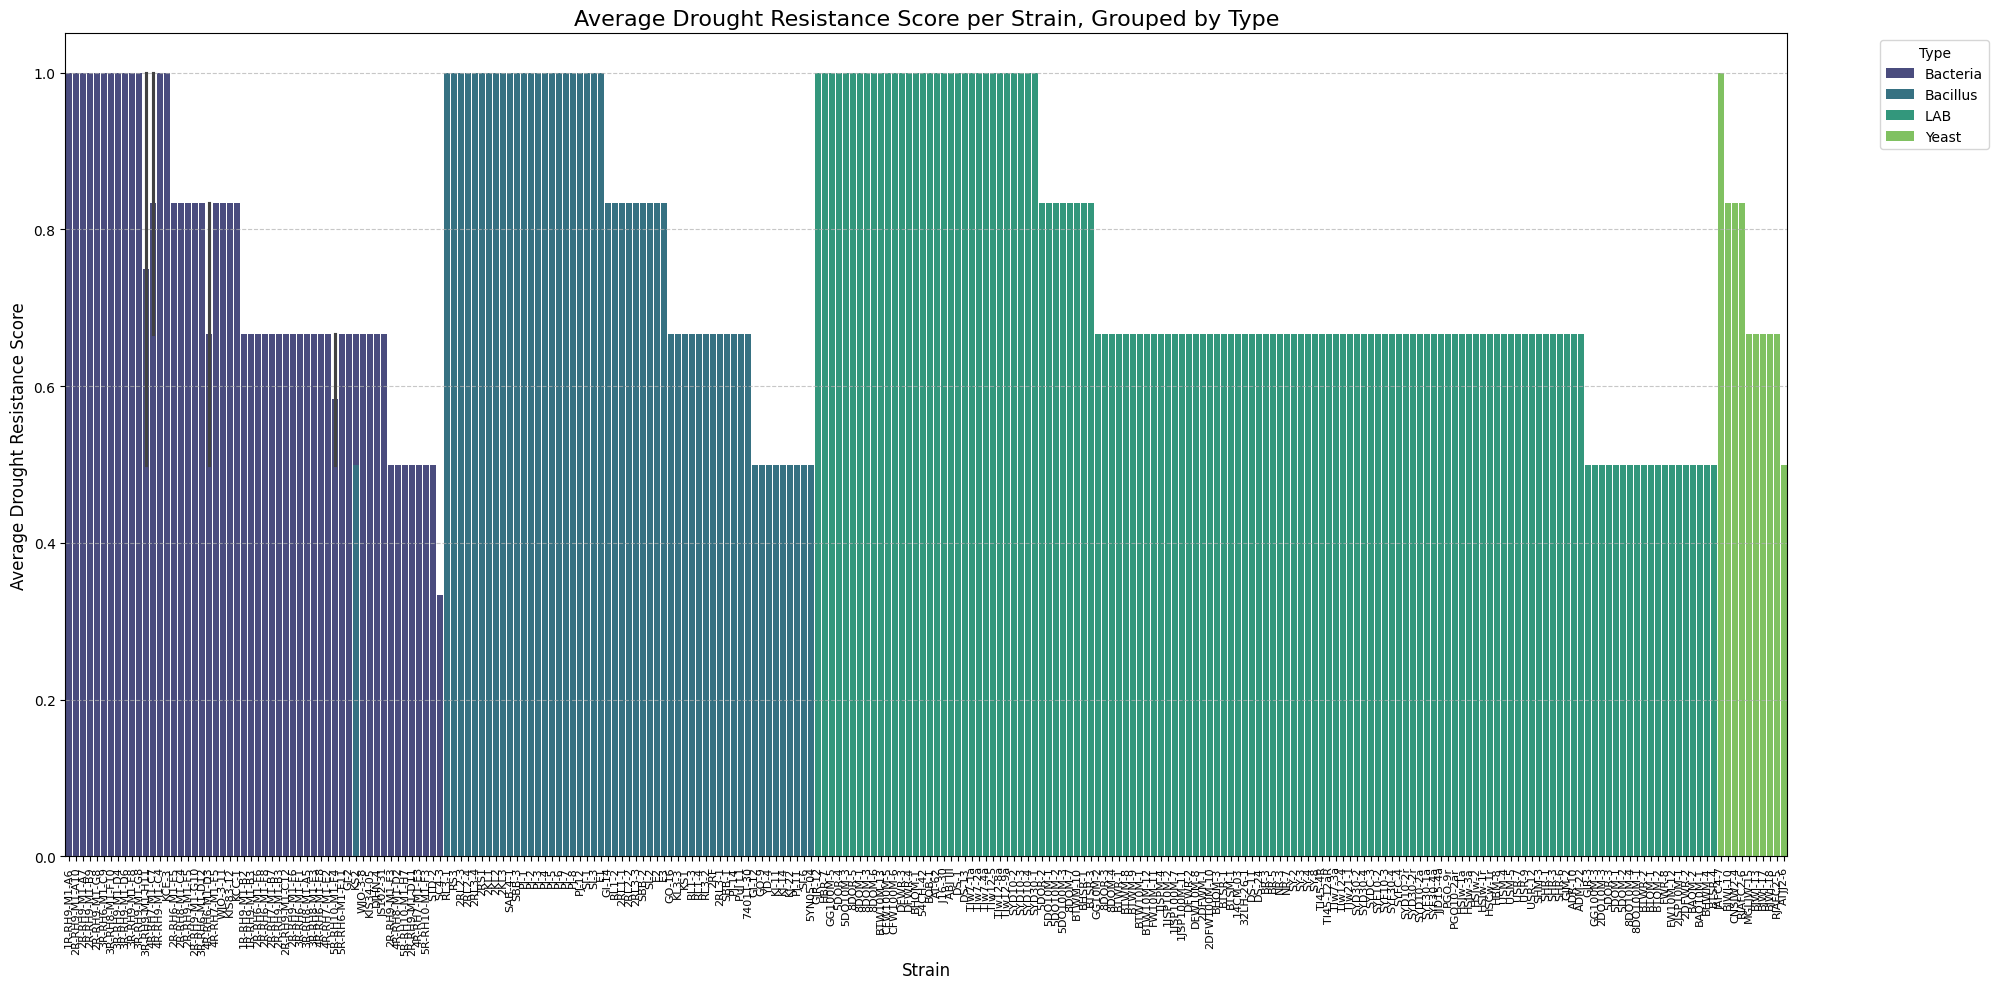

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the desired order for 'Type'
desired_order = ['Bacteria', 'Bacillus', 'LAB', 'Yeast']

# Convert 'Type' to a categorical type with the desired order
df['Type'] = pd.Categorical(df['Type'], categories=desired_order, ordered=True)

# Sort by Type and then by average resistance for better visualization
df_sorted = df.sort_values(by=['Type', 'average_resistance'], ascending=[True, False])

plt.figure(figsize=(20, 10)) # Increased figure size for better readability of many strains
sns.barplot(x='Strain', y='average_resistance', hue='Type', data=df_sorted, palette='viridis', dodge=False)

plt.title('Average Drought Resistance Score per Strain, Grouped by Type', fontsize=16)
plt.xlabel('Strain', fontsize=12)
plt.ylabel('Average Drought Resistance Score', fontsize=12)
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for better readability
plt.yticks(fontsize=10)
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show()

### Boxplot of Average Drought Resistance by Type

This boxplot will illustrate the distribution of average drought resistance scores for each organism 'Type'. It provides insights into the median, quartiles, and any potential outliers within each category, while maintaining the specified order of types.

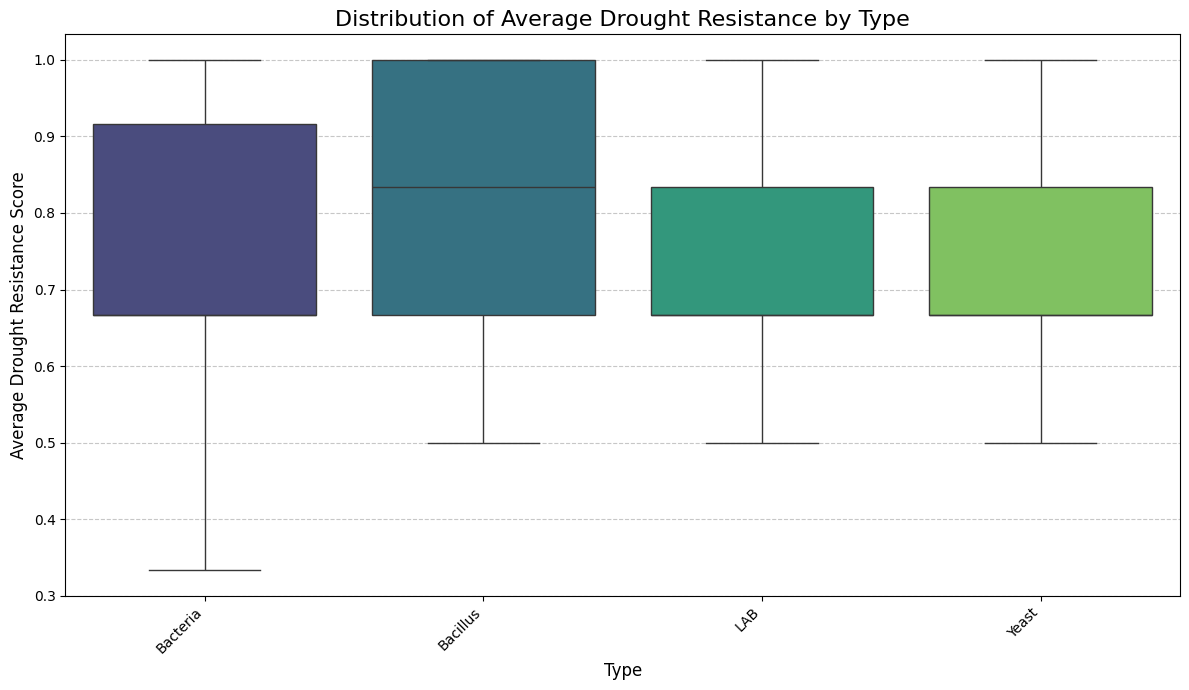

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Type' is categorical with the desired order for plotting
desired_order = ['Bacteria', 'Bacillus', 'LAB', 'Yeast']
df['Type'] = pd.Categorical(df['Type'], categories=desired_order, ordered=True)

plt.figure(figsize=(12, 7))
sns.boxplot(x='Type', y='average_resistance', hue='Type', data=df, palette='viridis', legend=False)
# sns.stripplot(x='Type', y='average_resistance', data=df, color='black', size=4, alpha=0.7, jitter=0.2) # Removed stripplot

plt.title('Distribution of Average Drought Resistance by Type', fontsize=16)
plt.xlabel('Type', fontsize=12)
plt.ylabel('Average Drought Resistance Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualization of Drought Resistance (Original Strain Order)

This new plot will display the average drought resistance for each strain, maintaining their original order as they appear in the dataset. The strains will still be colored and grouped by their 'Type' (Bacteria, Bacillus, LAB, Yeast) for consistent comparison.

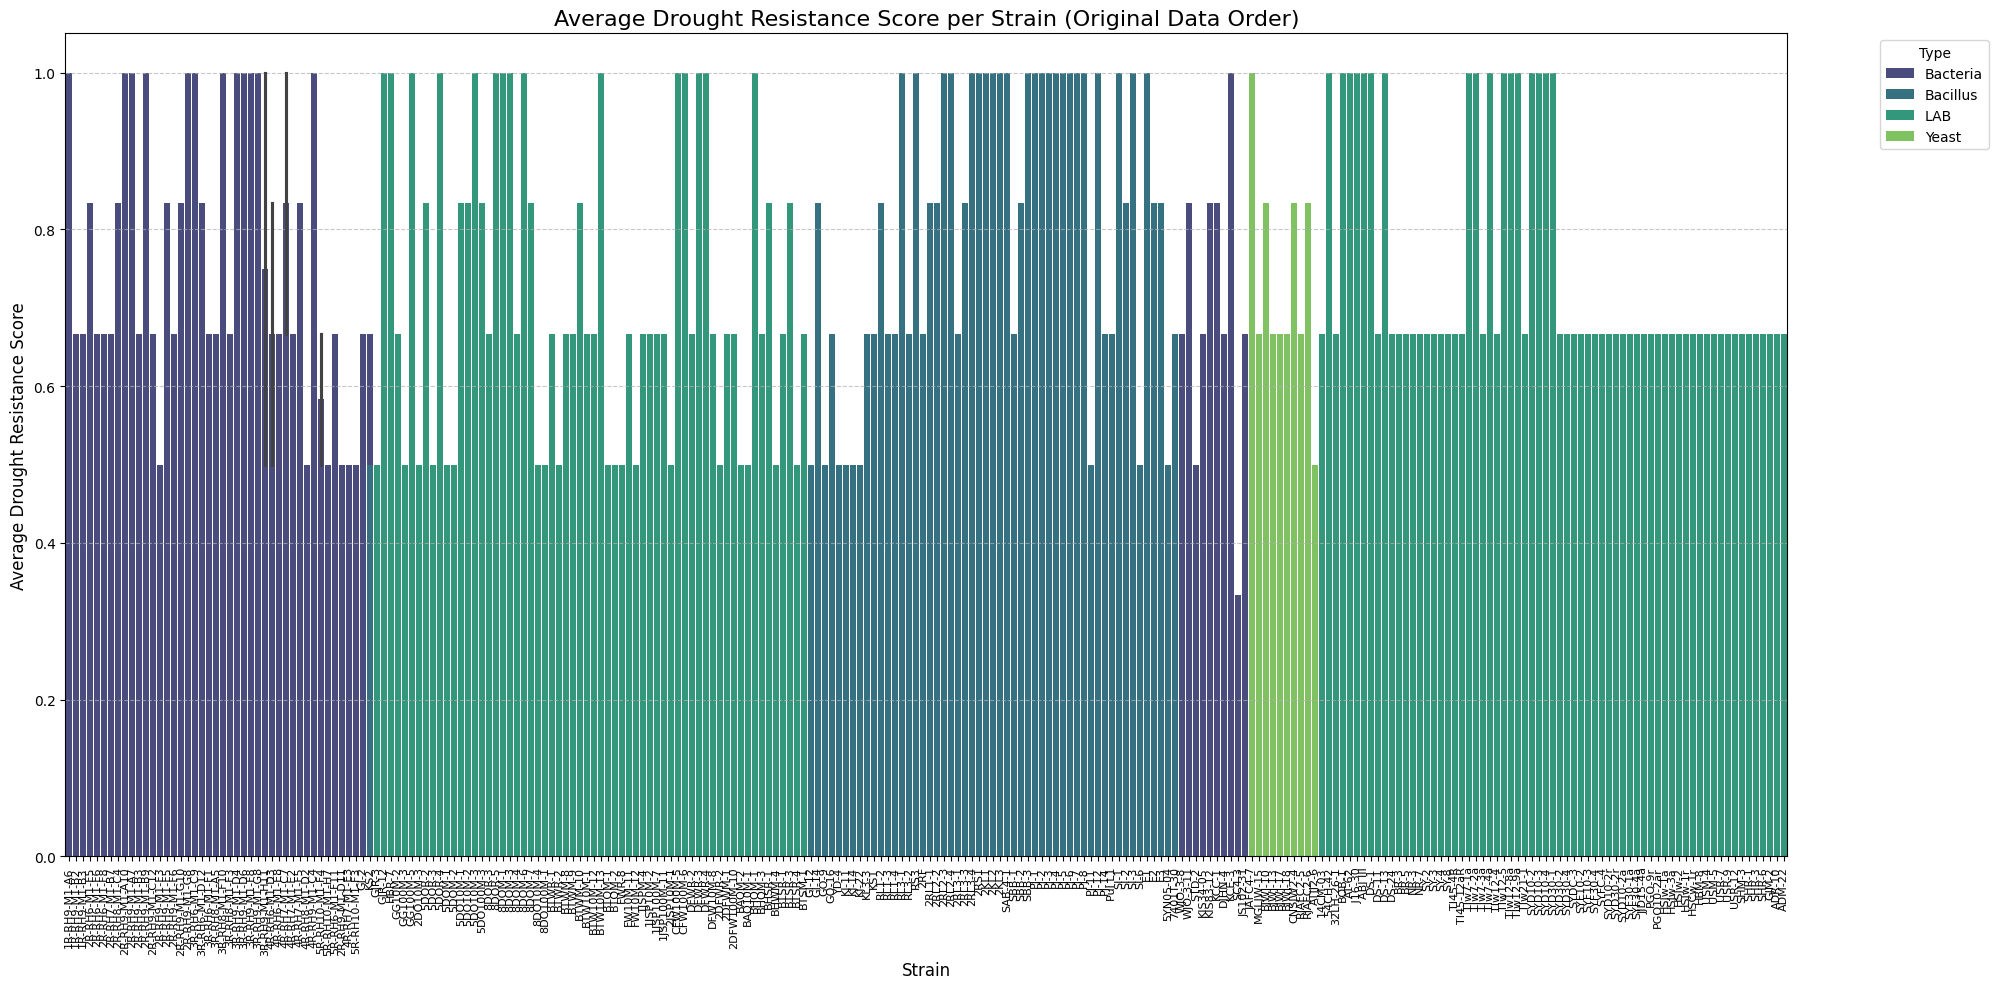

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the desired order for 'Type' (already set in df, but good for clarity)
desired_order = ['Bacteria', 'Bacillus', 'LAB', 'Yeast']

# Ensure 'Type' is categorical with the desired order (in case df was reset or for a new session)
# df['Type'] = pd.Categorical(df['Type'], categories=desired_order, ordered=True)
# Note: The 'Type' column in 'df' should already be categorical with the correct order from the previous plot.

plt.figure(figsize=(20, 10)) # Increased figure size for better readability
sns.barplot(x='Strain', y='average_resistance', hue='Type', data=df, palette='viridis', dodge=False)

plt.title('Average Drought Resistance Score per Strain (Original Data Order)', fontsize=16)
plt.xlabel('Strain', fontsize=12)
plt.ylabel('Average Drought Resistance Score', fontsize=12)
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for better readability
plt.yticks(fontsize=10)
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show()

### Summary Statistics by Type

I will now calculate the summary statistics (mean, standard deviation, min, max, etc.) for the `average_resistance` score, grouped by the `Type` of organism. This will help us understand the distribution of drought resistance within each category.

In [5]:
summary_stats = df.groupby('Type')['average_resistance'].describe()
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
Bacillus,54.0,0.805556,0.196270,0.500000,0.666667,0.833333,1.000000,1.0
Bacteria,59.0,0.745763,0.184027,0.333333,0.666667,0.666667,0.916667,1.0
LAB,129.0,0.735142,0.170034,0.500000,0.666667,0.666667,0.833333,1.0
Yeast,10.0,0.733333,0.140546,0.500000,0.666667,0.666667,0.833333,1.0


### Reordering Summary Statistics Table

I will now reorder the summary statistics table to follow the sequence: Bacteria, Bacillus, LAB, and Yeast, for better comparison as requested.

In [6]:
desired_order = ['Bacteria', 'Bacillus', 'LAB', 'Yeast']
summary_stats_ordered = summary_stats.reindex(desired_order)
display(summary_stats_ordered)

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
Bacteria,59.0,0.745763,0.184027,0.333333,0.666667,0.666667,0.916667,1.0
Bacillus,54.0,0.805556,0.196270,0.500000,0.666667,0.833333,1.000000,1.0
LAB,129.0,0.735142,0.170034,0.500000,0.666667,0.666667,0.833333,1.0
Yeast,10.0,0.733333,0.140546,0.500000,0.666667,0.666667,0.833333,1.0


### 한글 폰트 설정 및 시각화 경고 해결

시각화 결과에 한글이 깨지는 문제를 해결하고 Seaborn의 `FutureWarning`을 제거하기 위해 다음 단계를 진행합니다.

1.  **나눔 폰트 설치:** Matplotlib에서 한글을 올바르게 표시할 수 있도록 '나눔고딕' 폰트를 설치합니다.
2.  **Matplotlib 폰트 설정:** 설치된 폰트를 Matplotlib의 기본 폰트로 지정합니다.
3.  **Seaborn 경고 해결:** `sns.barplot` 호출 시 `hue` 파라미터를 명시하여 `FutureWarning`을 제거합니다.

In [29]:
# 폰트 설치 (한글 사용 시 필요 - 현재 그래프에서는 영어만 사용하므로 이 설정은 불필요)
# !apt-get update -qq
# !apt-get install fonts-nanum* -qq

# 폰트 설정 (한글 사용 시 필요)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
# font = fm.FontProperties(fname=fontpath, size=9)
# fm._rebuild() # matplotlib 3.2+ 에서는 불필요하거나 다른 방식으로 처리됨

# Matplotlib 런타임에 폰트 적용 (한글 사용 시 필요)
# plt.rc('font', family='NanumBarunGothic')
# plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


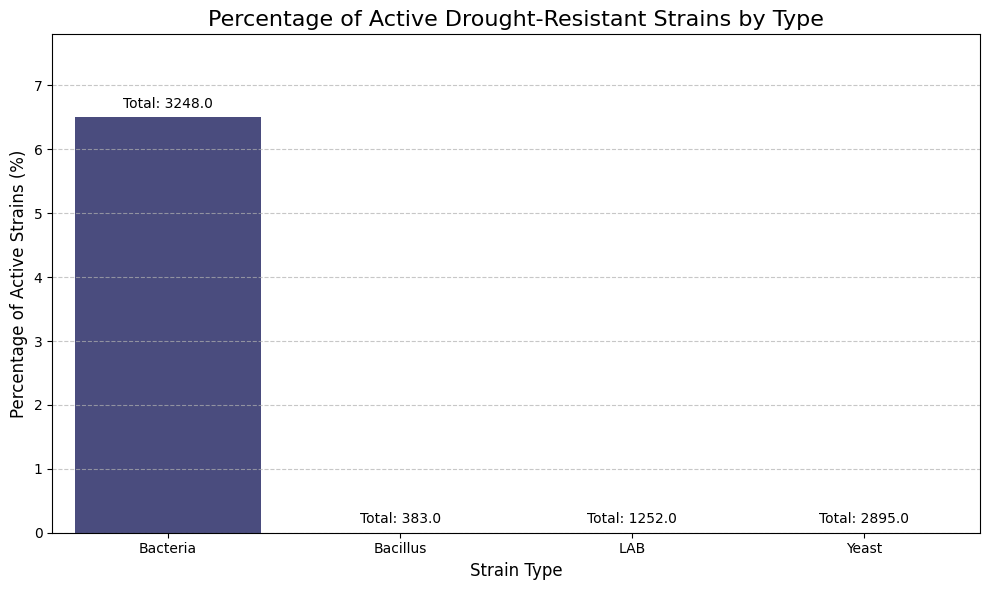

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for percentage_active
plt.figure(figsize=(10, 6))
sns.barplot(x=type_summary.index, y='percentage_active', hue=type_summary.index, data=type_summary, palette='viridis', legend=False) # Fix FutureWarning

# Add total strain counts on top of bars
for index, row in type_summary.iterrows():
    plt.text(index, row['percentage_active'] + 0.1, f"Total: {row['total_strains']}", color='black', ha="center", va='bottom')

plt.title('Percentage of Active Drought-Resistant Strains by Type', fontsize=16) # English Title
plt.xlabel('Strain Type', fontsize=12) # English Label
plt.ylabel('Percentage of Active Strains (%)', fontsize=12) # English Label
plt.ylim(0, type_summary['percentage_active'].max() * 1.2) # Adjust y-axis limit to fit text
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 타입별 활성 균주 비율 시각화

앞서 정리한 요약표를 바탕으로 각 타입별 활성 건조 저항성 균주의 비율을 막대 그래프로 시각화합니다. 이는 전체 균주 수 대비 활성 균주의 분포를 한눈에 파악하는 데 도움을 줄 것입니다.

/tmp/ipykernel_719/1210427506.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_summary.index, y='percentage_active', data=type_summary, palette='viridis')
/tmp/ipykernel_719/1210427506.py:17: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_719/1210427506.py:17: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_719/1210427506.py:17: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_719/1210427506.py:17: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_719/1210427506.py:17: UserWarning: Glyph 54876 (\N{HANGUL SYLLABLE HWAL}) missing from font(s) Deja

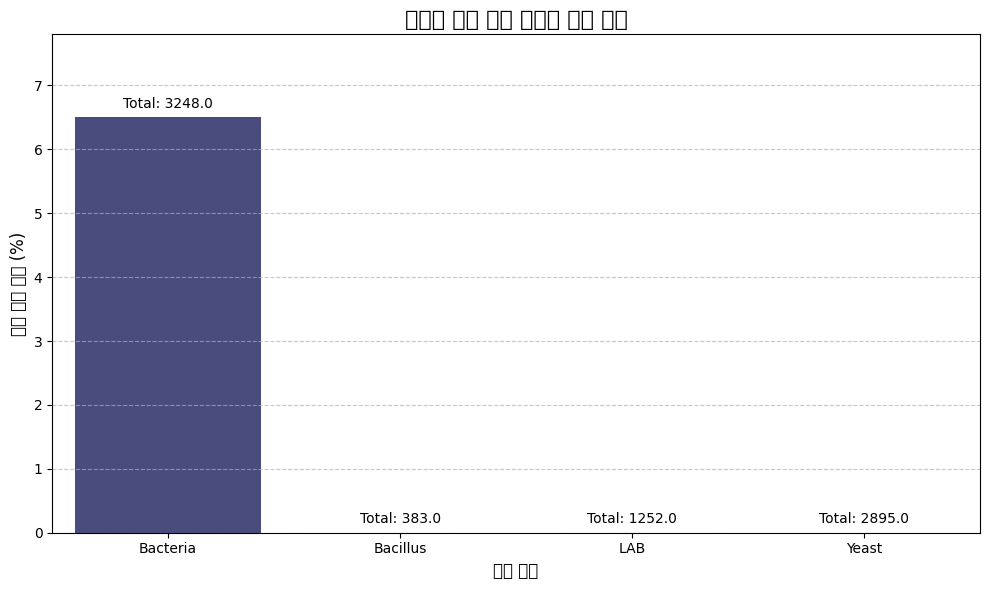

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for percentage_active
plt.figure(figsize=(10, 6))
sns.barplot(x=type_summary.index, y='percentage_active', data=type_summary, palette='viridis')

# Add total strain counts on top of bars
for index, row in type_summary.iterrows():
    plt.text(index, row['percentage_active'] + 0.1, f"Total: {row['total_strains']}", color='black', ha="center", va='bottom')

plt.title('타입별 활성 건조 저항성 균주 비율', fontsize=16)
plt.xlabel('균주 타입', fontsize=12)
plt.ylabel('활성 균주 비율 (%)', fontsize=12)
plt.ylim(0, type_summary['percentage_active'].max() * 1.2) # Adjust y-axis limit to fit text
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()